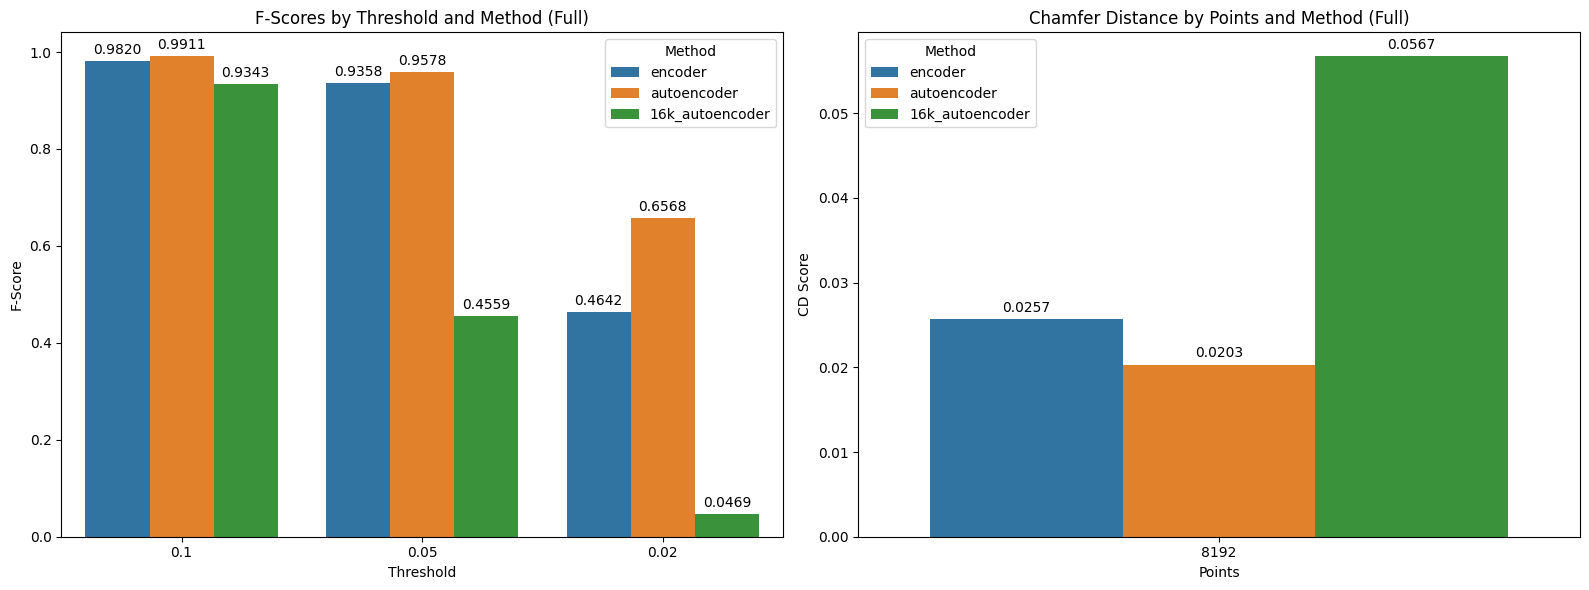

In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load JSON
with open('overfit.json', 'r') as f:
    data = json.load(f)

f_scores = []
cd_scores = []

# Parse the data
for method, metrics_list in data.items():
    if not metrics_list:
        continue
    
    entry = metrics_list[0]
    
    # Extract F-scores (ending with _full)
    f_keys = [k for k in entry.keys() if 'f_score' in k and k.endswith('_full')]
    for k in f_keys:
        threshold = k.replace('f_score_', '').replace('_full', '')
        f_scores.append({
            'Method': method,
            'Threshold': threshold,
            'F-Score': entry[k][0]
        })
    
    # Extract CD scores (ending with _full)
    cd_keys = [k for k in entry.keys() if 'CD' in k and k.endswith('_full')]
    for k in cd_keys:
        points = k.replace('CD_', '').replace('_full', '')
        cd_scores.append({
            'Method': method,
            'Points': points,
            'CD Score': entry[k][0]
        })

# Create DataFrames
df_f = pd.DataFrame(f_scores)
df_cd = pd.DataFrame(cd_scores)

# Plot as Seaborn Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F-Scores Bar Chart
ax0 = sns.barplot(data=df_f, x='Threshold', y='F-Score', hue='Method', ax=axes[0])
axes[0].set_title('F-Scores by Threshold and Method (Full)')
for container in ax0.containers:
    ax0.bar_label(container, fmt='%.4f', padding=3)

# CD Scores Bar Chart
ax1 = sns.barplot(data=df_cd, x='Points', y='CD Score', hue='Method', ax=axes[1])
axes[1].set_title('Chamfer Distance by Points and Method (Full)')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()